In [7]:
import json, os
import pandas as pd
import numpy as np
import geopandas as gpd
import osmnx as ox
from matplotlib import pyplot as plt
import networkx as nx
from tqdm import tqdm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib

In [8]:
# import lts calculation functions
from lts_functions import (biking_permitted, is_separated_path, is_bike_lane, parking_present,
                           bike_lane_analysis_no_parking, bike_lane_analysis_with_parking, mixed_traffic)

# ## Extract OSM tags to use in download


f = open("victoriaosm.osm") # a larger bounding box for the city
data = json.load(f)

# +
# make a dataframe of tags
dfs = []

for element in data['elements']:
    if element['type'] != 'way':
        continue
    df = pd.DataFrame.from_dict(element['tags'], orient = 'index')
    dfs.append(df)
# -

tags_df = pd.concat(dfs).reset_index()
tags_df.columns = ["tag", "tagvalue"]

tag_value_counts = tags_df.value_counts().reset_index() # count all the unique tag and value combinations
tag_counts = tags_df['tag'].value_counts().reset_index() # count all the unique tags

print(tag_counts)

# explore the tags that start with 'cycleway'
tag_counts[tag_counts['tag'].str.contains('cycleway')]

way_tags = list(tag_counts['tag']) # all unique tags from the OSM Toronto download

# add the above list to the global osmnx settings
ox.settings.useful_tags_way += way_tags
ox.settings.osm_xml_way_tags = way_tags

                      tag  count
0                 highway  18306
1                 surface   8819
2                    name   6221
3                sidewalk   4609
4                maxspeed   3915
..                    ...    ...
253  payment:credit_cards      1
254   payment:debit_cards      1
255  parking:left:maxstay      1
256         class:bicycle      1
257             sac_scale      1

[258 rows x 2 columns]


In [ ]:
# ### Download data

# create a filter to download selected data
# this filter is based on osmfilter = ox.downloader._get_osm_filter("bike")
# keeping the footway and construction tags
osmfilter = '["highway"]["area"!~"yes"]["access"!~"private"]["highway"!~"abandoned|bus_guideway|corridor|elevator|escalator|motor|planned|platform|proposed|raceway|steps"]["bicycle"!~"no"]["service"!~"private"]'

city = "Irvine"
county= 'Orange'
state = "California"

In [ ]:
# check if data has already been downloaded; if not, download
filepath = "data/%s.graphml" %city
if os.path.exists(filepath):
    # load graph
    print("loading saved graph")
    G = ox.load_graphml(filepath)
else:
    # download data - this can be slow
    print("downloading data")
    G = ox.graph_from_place(
        "%s, %s, %s, USA" %(city, county, state),
        retain_all=True,
        truncate_by_edge=True,
        simplify=False,
        custom_filter=osmfilter,
    )
    # save graph
    print("saving graph")
    ox.save_graphml(G, filepath)

# plot downloaded graph - this is slow for a large area
fig, ax = ox.plot_graph(G, node_size=0, edge_color="w", edge_linewidth=0.2)
fig.savefig('data/plots/%s_fullnetwork.png'%city)

In [11]:
# ## Analyze LTS
#
# Start with is biking allowed, get edges where biking is not *not* allowed.

# convert graph to node and edge GeoPandas GeoDataFrames
gdf_nodes, gdf_edges = ox.graph_to_gdfs(G)
gdf_edges['width'] = pd.to_numeric(gdf_edges['width'], errors='coerce') #debug

print(gdf_edges.shape)
gdf_allowed, gdf_not_allowed = biking_permitted(gdf_edges)
print(gdf_allowed.shape)
print(gdf_not_allowed.shape)

# check for separated path
separated_edges, unseparated_edges = is_separated_path(gdf_allowed)
# assign separated ways lts = 1
separated_edges['lts'] = 1
print(separated_edges.shape)
print(unseparated_edges.shape)

to_analyze, no_lane = is_bike_lane(unseparated_edges)
print(to_analyze.shape)
print(no_lane.shape)

parking_detected, parking_not_detected = parking_present(to_analyze)
print(parking_detected.shape)
print(parking_not_detected.shape)

parking_lts = bike_lane_analysis_with_parking(parking_detected)

no_parking_lts = bike_lane_analysis_no_parking(parking_not_detected)

# Next, go to the last step - mixed traffic

lts_no_lane = mixed_traffic(no_lane)

# final components: lts_no_lane, parking_lts, no_parking_lts, separated_edges
# these should all add up to gdf_allowed
print(gdf_allowed.shape)
lts_no_lane.shape[0] + parking_lts.shape[0] + no_parking_lts.shape[0] + separated_edges.shape[0]

gdf_not_allowed['lts'] = 0

all_lts = pd.concat([separated_edges, parking_lts, no_parking_lts, lts_no_lane, gdf_not_allowed])

(410843, 113)
(321370, 114)
(89473, 114)
(130919, 115)
(190451, 113)
(15312, 113)
(175139, 113)
(0, 113)
(15312, 113)
(321370, 114)


In [12]:
# decision rule glossary
# these are from Bike Ottawa's stressmodel code
rule_message_dict = {'p2':'Cycling not permitted due to bicycle=\'no\' tag.',
                     'p6':'Cycling not permitted due to access=\'no\' tag.',
                     'p3':'Cycling not permitted due to highway=\'motorway\' tag.',
                     'p4':'Cycling not permitted due to highway=\'motorway_link\' tag.',
                     'p7':'Cycling not permitted due to highway=\'proposed\' tag.',
                     'p5':'Cycling not permitted. When footway="sidewalk" is present, there must be a bicycle="yes" when the highway is "footway" or "path".',
                     's3':'This way is a separated path because highway=\'cycleway\'.',
                     's1':'This way is a separated path because highway=\'path\'.',
                     's2':'This way is a separated path because highway=\'footway\' but it is not a crossing.',
                     's7':'This way is a separated path because cycleway* is defined as \'track\'.',
                     's8':'This way is a separated path because cycleway* is defined as \'opposite_track\'.',
                     'b1':'LTS is 1 because there is parking present, the maxspeed is less than or equal to 40, highway="residential", and there are 2 lanes or less.',
                     'b2':'Increasing LTS to 3 because there are 3 or more lanes and parking present.',
                     'b3':'Increasing LTS to 3 because the bike lane width is less than 4.1m and parking present.',
                     'b4':'Increasing LTS to 2 because the bike lane width is less than 4.25m and parking present.',
                     'b5':'Increasing LTS to 2 because the bike lane width is less than 4.5m, maxspeed is less than 40 on a residential street and parking present.',
                     'b6':'Increasing LTS to 2 because the maxspeed is between 41-50 km/h and parking present.',
                     'b7':'Increasing LTS to 3 because the maxspeed is between 51-54 km/h and parking present.',
                     'b8':'Increasing LTS to 4 because the maxspeed is over 55 km/h and parking present.',
                     'b9':'Increasing LTS to 3 because highway is not \'residential\'.',
                     'c1':'LTS is 1 because there is no parking, maxspeed is less than or equal to 50, highway=\'residential\', and there are 2 lanes or less.',
                     'c3':'Increasing LTS to 3 because there are 3 or more lanes and no parking.',
                     'c4':'Increasing LTS to 2 because the bike lane width is less than 1.7 metres and no parking.',
                     'c5':'Increasing LTS to 3 because the maxspeed is between 51-64 km/h and no parking.',
                     'c6':'Increasing LTS to 4 because the maxspeed is over 65 km/h and no parking.',
                     'c7':'Increasing LTS to 3 because highway with bike lane is not \'residential\' and no parking.',
                     'm17':'Setting LTS to 1 because motor_vehicle=\'no\'.',
                     'm13':'Setting LTS to 1 because highway=\'pedestrian\'.',
                     'm14':'Setting LTS to 2 because highway=\'footway\' and footway=\'crossing\'.',
                     'm2':'Setting LTS to 2 because highway=\'service\' and service=\'alley\'.',
                     'm15':'Setting LTS to 2 because highway=\'track\'.',
                     'm3':'Setting LTS to 2 because maxspeed is 50 km/h or less and service is \'parking_aisle\'.',
                     'm4':'Setting LTS to 2 because maxspeed is 50 km/h or less and service is \'driveway\'.',
                     'm16':'Setting LTS to 2 because maxspeed is less than 35 km/h and highway=\'service\'.',
                     'm5':'Setting LTS to 2 because maxspeed is up to 40 km/h, 3 or fewer lanes and highway=\'residential\'.',
                     'm6':'Setting LTS to 3 because maxspeed is up to 40 km/h and 3 or fewer lanes on non-residential highway.',
                     'm7':'Setting LTS to 3 because maxspeed is up to 40 km/h and 4 or 5 lanes.',
                     'm8':'Setting LTS to 4 because maxspeed is up to 40 km/h and the number of lanes is greater than 5.',
                     'm9':'Setting LTS to 2 because maxspeed is up to 50 km/h and lanes are 2 or less and highway=\'residential\'.',
                     'm10':'Setting LTS to 3 because maxspeed is up to 50 km/h and lanes are 3 or less on non-residential highway.',
                     'm11':'Setting LTS to 4 because the number of lanes is greater than 3.',
                     'm12':'Setting LTS to 4 because maxspeed is greater than 50 km/h.'}


In [13]:
simplified_message_dict = {'p2':r'bicycle $=$ "no"',
                     'p6':r'access $=$ "no"',
                     'p3':r'highway $=$ "motorway"',
                     'p4':r'highway $=$ "motorway_link"',
                     'p7':r'highway $=$ "proposed"',
                     'p5':r'footway $=$ "sidewalk", bicycle$\neq$"yes"',
                     's3':r'highway $=$ "cycleway"',
                     's1':r'highway $=$" path"',
                     's2':r'separated, highway $=$" footway", not a crossing',
                     's7':r'cycleway* $=$ "track"',
                     's8':r'cycleway* $=$ "opposite_track"',
                     'b1':r'bike lane w/ parking, $\leq$ 40 km/h, highway $=$ "residential", $\leq$ 2 lanes',
                     'b2':r'bike lane w/ parking, 3 or more lanes',
                     'b3':r'bike lane width $<$ 4.1m, parking',
                     'b4':r'bike lane width $<$ 4.25m, parking',
                     'b5':r'bike lane width $<$ 4.5m, $\leq$ 40 km/h, residential, parking',
                     'b6':r'bike lane w/ parking, speed 41-50 km/h',
                     'b7':r'bike lane w/ parking, speed 51-54 km/h',
                     'b8':r'bike lane w/ parking, speed $>$ 55 km/h',
                     'b9':r'bike lane w/ parking, highway $\neq$ "residential"',
                     'c1':r'bike lane no parking, $\leq$ 50 km/h, highway $=$ "residential", $\leq$ 2 lanes',
                     'c3':r'bike lane no parking, $\leq$ 65 km/h, $\geq$ 3 lanes',
                     'c4':r'bike lane width $<$ 1.7m, no parking',
                     'c5':r'bike lane no parking, speed 51-64 km/h',
                     'c6':r'bike lane no parking, speed $>$ 65 km/h',
                     'c7':r'bike lane no parking, highway $\neq$ "residential"',
                     'm17':r'mixed traffic, motor_vehicle $=$ "no"',
                     'm13':r'mixed traffic, highway $=$ "pedestrian"',
                     'm14':r'mixed traffic, highway $=$ "footway", footway $=$ "crossing"',
                     'm2':r'mixed traffic, highway $=$ "service", service $=$ "alley"',
                     'm15':r'mixed traffic, highway $=$ "track"',
                     'm3':r'mixed traffic, speed $\leq$ 50 km/h, service $=$ "parking_aisle"',
                     'm4':r'mixed traffic, speed $\leq$ 50 km/h, service $=$ "driveway"',
                     'm16':r'mixed traffic, speed $\leq$ 35 km/h, highway $=$ "service"',
                     'm5':r'mixed traffic, speed $\leq$ 40 km/h, highway $=$ "residential", $\leq$ 3 lanes',
                     'm6':r'mixed traffic, speed $\leq$ 40 km/h, highway $\neq$ "residential", $\leq$ 3 lanes',
                     'm7':r'mixed traffic, speed $\leq$ 40 km/h, 4 or 5 lanes',
                     'm8':r'mixed traffic, speed $\leq$ 40 km/h, lanes $>$ 5',
                     'm9':r'mixed traffic, speed $\leq$ 50 km/h, highway $=$ "residential",$\leq$ 2 lanes',
                     'm10':r'mixed traffic, speed $\leq$ 50 km/h, highway $\neq$ "residential", $\leq$ 3 lanes',
                     'm11':r'mixed traffic, speed $\leq$ 50 km/h, lanes $>$ 3',
                     'm12':r'mixed traffic, speed $>$ 50 km/h'}

all_lts['message'] = all_lts['rule'].map(rule_message_dict)
all_lts['short_message'] = all_lts['rule'].map(simplified_message_dict)


In [14]:
# ## Node LTS
#
# Calculate node LTS.
#
# - An intersection without either was assigned the highest LTS of its intersecting roads.
# - Stop signs reduced an otherwise LTS2 intersection to LTS1.
# - A signalized intersection of two lowstress links was assigned LTS1.
# - Assigned LTS2 to signalized intersections where a low-stress (LTS1/ 2) link crosses a high-stress (LTS3/4) link.

gdf_nodes['highway'].value_counts()

# +
gdf_nodes['lts'] = np.nan # make lts column
gdf_nodes['message'] = '' # make message column

for node in tqdm(gdf_nodes.index):
    try:
        edges = all_lts.loc[node]
    except:
        #print("Node not found in edges: %s" %node)
        gdf_nodes.loc[node, 'message'] = "Node not found in edges"
        continue
    control = gdf_nodes.loc[node,'highway'] # if there is a traffic control
    max_lts = edges['lts'].max()
    node_lts = int(max_lts) # set to max of intersecting roads
    message = "Node LTS is max intersecting LTS"
    if node_lts > 2:
        if control == 'traffic_signals':
            node_lts = 2
            message = "LTS 3-4 with traffic signals"
    elif node_lts <= 2:
        if control == 'traffic_signals' or control == 'stop':
            node_lts = 1
            message = "LTS 1-2 with traffic signals or stop"

    gdf_nodes.loc[node,'message'] = message
    gdf_nodes.loc[node,'lts'] = node_lts # assign node lts
# -


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 197147/197147 [13:12<00:00, 248.77it/s]


In [15]:
# ### Save data for plotting

gdf_nodes.to_csv("data/gdf_nodes_%s.csv" %city)

all_lts_small = all_lts[['osmid', 'lanes', 'name', 'highway', 'maxspeed', 'geometry', 'length', 'rule', 'lts',
                         'lanes_assumed', 'maxspeed_assumed', 'message', 'short_message']]
all_lts_small.to_csv("data/all_lts_%s.csv" %city)

# make graph with LTS information
#G_lts = ox.graph_from_gdfs(gdf_nodes, all_lts_small)
G_lts = ox.graph_from_gdfs(gdf_nodes[(gdf_nodes['lts']!=0)], all_lts_small[(all_lts_small['lts']!=0)]) #don't include "LTS = 0" --> bicycles not allowed

# save LTS graph
#filepath = "data/%s_lts.graphml" %city
#ox.save_graphml(G_lts, filepath)



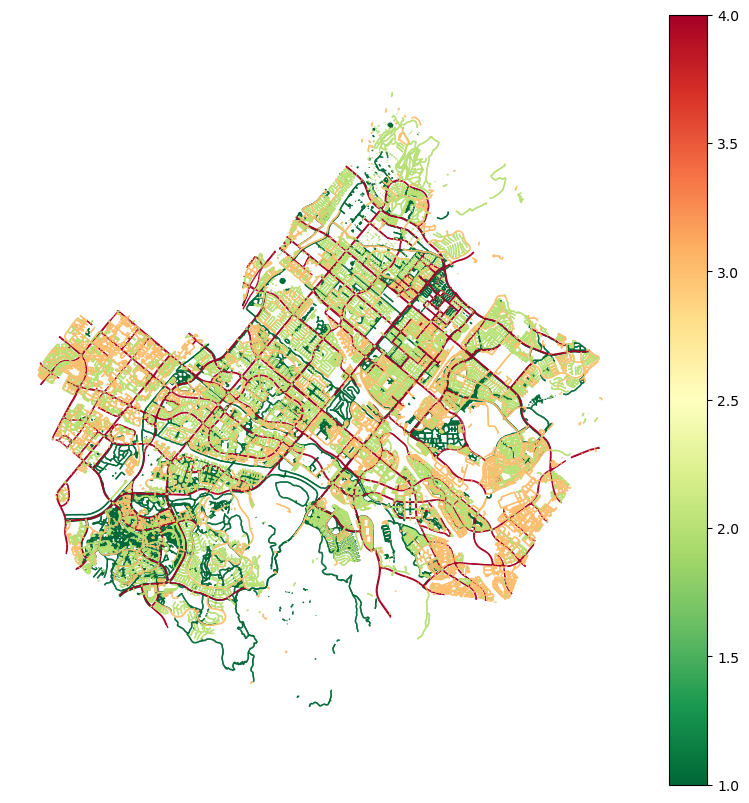

In [16]:
## All ways LTS
fig1, ax1 = plt.subplots(figsize=(10,10))

all_lts_small[(all_lts_small['lts']<=4) & (all_lts_small['lts']!=0)].plot(
    ax=ax1,
    column="lts",
    linewidth=1,
    cmap='RdYlGn_r',
    legend=True)

ax1.axis("off")
plt.show()
fig1.savefig('data/plots/%s_lts_ways.png'%city)

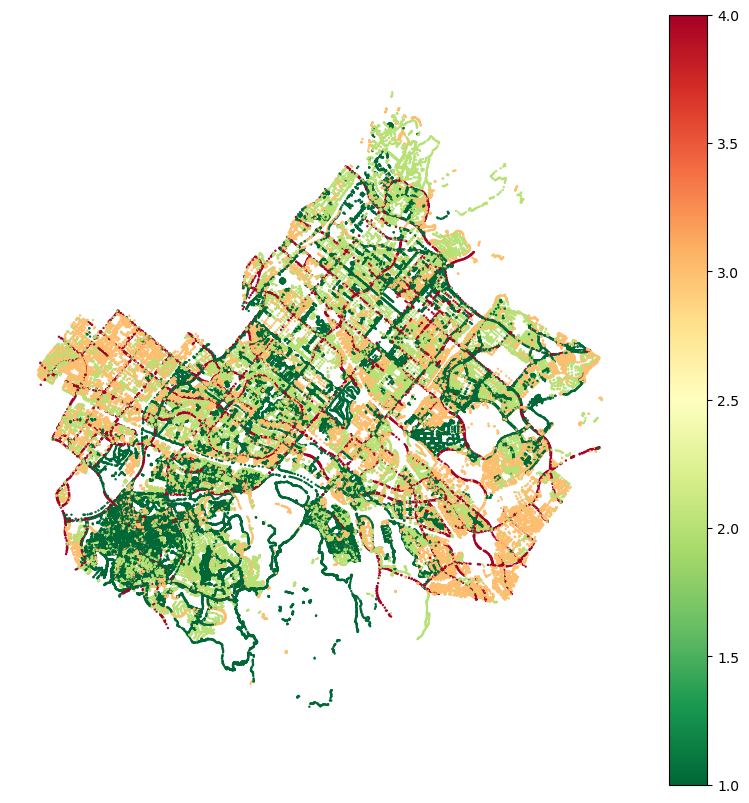

In [17]:
## All nodes LTS

fig2, ax2 = plt.subplots(figsize=(10,10))

gdf_nodes[(gdf_nodes['lts']<=4) & (gdf_nodes['lts']!=0)].plot(
    ax=ax2,
    column="lts",
    markersize=0.5,
    linewidth=1,
    cmap='RdYlGn_r',
    legend=True)

ax2.axis("off")
plt.show()
fig2.savefig('data/plots/%s_lts_nodes.png'%city)

In [55]:
## Filtered network: create LTS<=2 and LTS=1 moderate/low-stress and true low-stress networks

nodes_lts2=gdf_nodes[(gdf_nodes['lts']<=2) & (gdf_nodes['lts']!=0)]
nodes_lts1=gdf_nodes[(gdf_nodes['lts']<=1) & (gdf_nodes['lts']!=0)]

edges_lts2=all_lts_small[(all_lts_small['lts']<=2) & (all_lts_small['lts']!=0)]
edges_lts1=all_lts_small[(all_lts_small['lts']<=1) & (all_lts_small['lts']!=0)]

In [56]:
## Convert low-stress networks to graphs
G_low_stress2=ox.graph_from_gdfs(gdf_nodes[(gdf_nodes['lts']<=2) & (gdf_nodes['lts']!=0)]
                   ,all_lts_small[(all_lts_small['lts']<=2) & (all_lts_small['lts']!=0)])
G_low_stress1=ox.graph_from_gdfs(gdf_nodes[(gdf_nodes['lts']<=1) & (gdf_nodes['lts']!=0)]
                   ,all_lts_small[(all_lts_small['lts']<=1) & (all_lts_small['lts']!=0)])

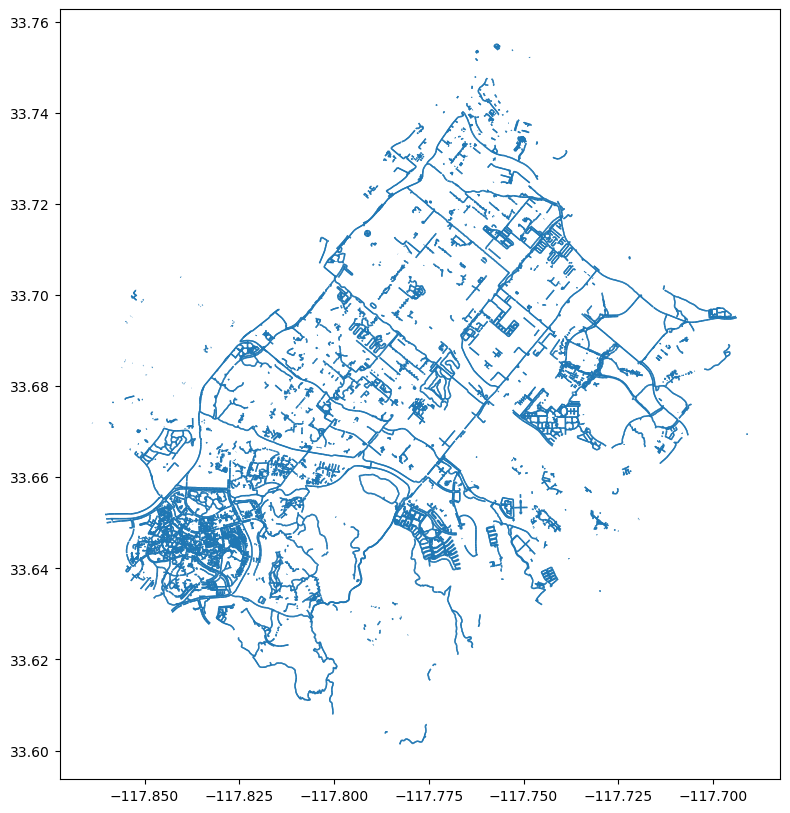

In [20]:
## Plot LTS =1 network
fig3, ax3 = plt.subplots(figsize=(10,10))

edges_lts1.plot(
    ax=ax3,
    #column="lts",
    linewidth=1,
    #cmap='YlGn_r',
    legend=True)

ax1.axis("off")
plt.show()

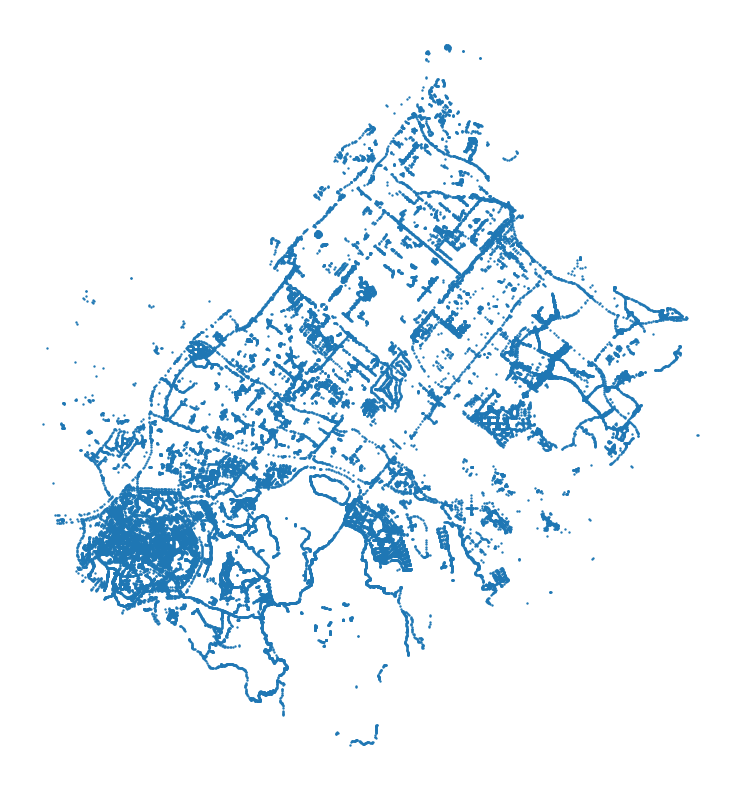

In [21]:
## Filtered LTS <=2
fig4, ax4 = plt.subplots(figsize=(10,10))

nodes_lts1.plot(
    ax=ax4,
    #column="lts",
    markersize=0.5,
    linewidth=1,
    #cmap=cmap,
    legend=True)

ax4.axis("off")
plt.show()

In [22]:
#fig, ax = ox.plot_graph(G_lts, node_color='r', edge_linewidth=0.3)

In [23]:
## Filtered network graph with only low-stress ways/nodes - remove all ways/nodes with LTS above 2
#G_low_stress = G_lts.copy().to_undirected()
#G_low_stress.remove_nodes_from(gdf_nodes[(gdf_nodes['lts']>2)])
#G_low_stress.remove_edges_from(all_lts_small[all_lts_small['lts']>2])



# save LTS graph
#filepath = "data/%s_low_stress.graphml" %city
#ox.save_graphml(G_lts, filepath)

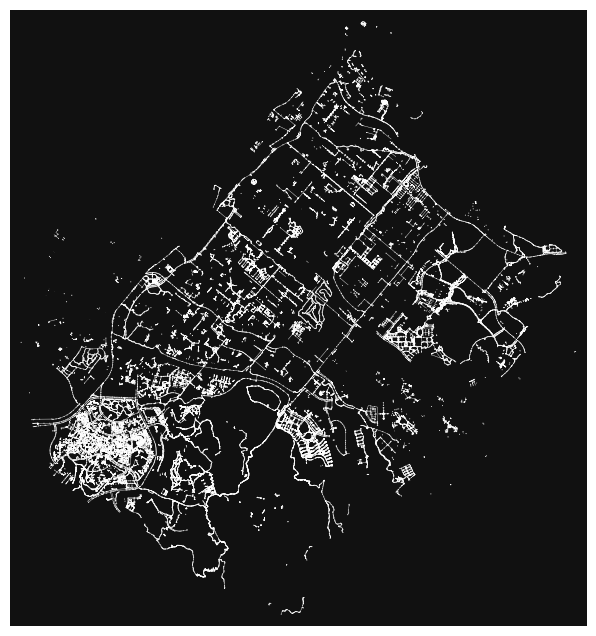

In [24]:
fig5, ax5 = ox.plot_graph(G_low_stress1, node_size=0.5, edge_linewidth=0.3)

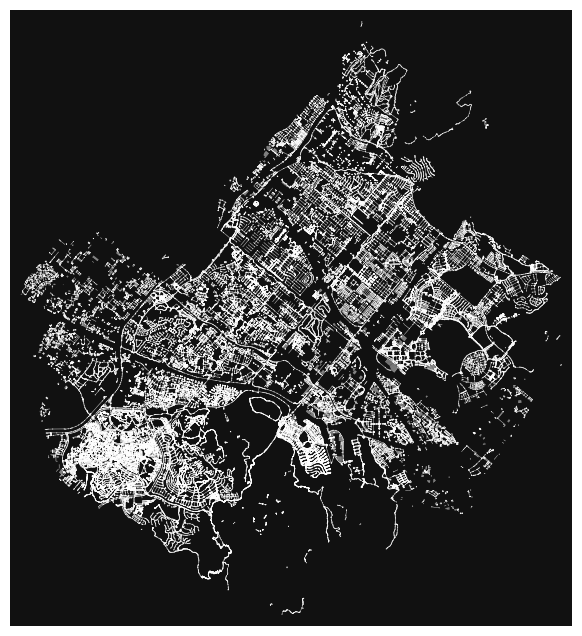

In [25]:
fig6, ax6 = ox.plot_graph(G_low_stress2, node_size=0.5, edge_linewidth=0.3)
#fig5.savefig('data/plots/%s_low_stress1.png'%city)

In [26]:
#Compare to original:
#fig, ax = ox.plot_graph(G_lts, node_size=0.5, edge_linewidth=0.3)
## Not able to plot G_lts or convert it back to gdfs for some reason ....
## so note that this still incldes sidewalks and other LTS=0 places where biking is not permitted
## Actually, instead make a new graph where LTS=0 is filtered out
#G_all_biking=ox.graph_from_gdfs(gdf_nodes[(gdf_nodes['lts']!=0)]
#                   ,all_lts_small[(all_lts_small['lts']!=0)])

#G_all_biking=ox.graph_from_gdfs(gdf_nodes[(gdf_nodes['lts']<=2) & (gdf_nodes['lts']!=0)]
#                   ,all_lts_small[(all_lts_small['lts']<=2) & (all_lts_small['lts']!=0)])
#fig6, ax6 = ox.plot_graph(G_all_biking, node_size=0.5, edge_linewidth=0.3)
#fig6.savefig('data/plots/%s_all_biking.png'%city)

In [27]:
#nodes_gdf_low_stress, edges_gdf_low_stress = ox.graph_to_gdfs(G_low_stress)

### PART 2: Connectivity metrics by census tract

#### Get Census Tracts

In [29]:
## import census tracts

import pycen
from pycen import explore, acquire
import pandas as pd

pycen_place = "%s city"%city
pycen_state = "CA"
dataset = "acs5"
year = 2019  # keep consistent across pycen calls

# Output 
#out_gpkg = "sanjose_voronoi_population_pycen.gpkg"

### Quick visualization of ridership per census tract

tracts = acquire.get_censhp(
    variables=['B08301_018E',"B01003_001E"],
    geography="tract",
    place=pycen_place,
    state=pycen_state,
    dataset=dataset,
    year=year
).rename(columns={'B08301_018E': "total_bike","B01003_001E":"total_pop"})

#tracts["total_bike"] = pd.to_numeric(tracts["total_bike"], errors="coerce").fillna(0)
#tracts['pct_bike']=tracts['total_bike']/tracts["total_pop"] *100

# Quick look
#tracts[["total_bike", "geometry"]].head()

## quick visualization
#acquire.quick_viz(tracts, "pct_bike")


Resolving geography...
  State: California (CA, FIPS: 06)
Loading from cache: pycen_cache/api/acs5_2019_tract_06__a5d52b32b125626b.csv
Loading boundaries from cache...
Merging data...
Clipping to place: Irvine city
Fetching boundaries...


In [30]:
## create boundaries for all census tracts in a city
## From assignment 2 voronoi code
bg = acquire.get_censhp(
    variables=["B19001_001E"],   # any variable is fine; we only need geometry
    geography="tract",
    place=pycen_place,
    state=pycen_state,
    dataset=dataset,
    year=year
)

boundary = bg.geometry
boundary

Resolving geography...
  State: California (CA, FIPS: 06)
Loading from cache: pycen_cache/api/acs5_2019_tract_06__d4a903a509b729a9.csv
Loading boundaries from cache...
Merging data...
Clipping to place: Irvine city
Fetching boundaries...


129     MULTIPOLYGON (((-117.83877 33.6576, -117.82776...
689     MULTIPOLYGON (((-117.7854 33.68909, -117.78266...
1201    MULTIPOLYGON (((-117.82748 33.66365, -117.8264...
1271    MULTIPOLYGON (((-117.78092 33.69526, -117.7782...
1272    MULTIPOLYGON (((-117.77188 33.70623, -117.7710...
1432    MULTIPOLYGON (((-117.74076 33.65581, -117.7385...
1533    MULTIPOLYGON (((-117.79129 33.66698, -117.791 ...
1668    MULTIPOLYGON (((-117.82309 33.69154, -117.8143...
1806    MULTIPOLYGON (((-117.83563 33.6783, -117.83535...
2487    MULTIPOLYGON (((-117.79625 33.69614, -117.7932...
2830    MULTIPOLYGON (((-117.77105 33.6646, -117.76162...
2857    MULTIPOLYGON (((-117.82069 33.6716, -117.81901...
2880    MULTIPOLYGON (((-117.84553 33.65559, -117.8370...
3000    MULTIPOLYGON (((-117.83483 33.67996, -117.8327...
3109    MULTIPOLYGON (((-117.83992 33.63204, -117.8357...
3115    MULTIPOLYGON (((-117.79904 33.67785, -117.7961...
3336    MULTIPOLYGON (((-117.82696 33.6344, -117.82576...
3416    MULTIP

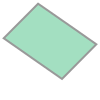

In [31]:
boundary_i=boundary.iloc[1]
boundary_i
## just choosing an arbitrary census tract for right now to experiment with

In [32]:
## Select nodes and edges located within census tract boundary


## NOTE/TODO for others working on this
## still have to change this to only be using the low-stress network
## (eg. filter gdf_nodes to only the low stress nodes and all_lts_small to only the low stress edges for the code below)
## also need to filter out LTS=0
## also need to eventually iterate/apply across all census tracts in the city
## But for now you can just try doing connectivity analysis on individual census tracts?
## then we can just run whatever analysis you come up with across all census tracts

nodes_in = gdf_nodes[gdf_nodes.geometry.within(boundary_i)].copy().reset_index(drop=False)
edges_in = all_lts_small[all_lts_small.geometry.within(boundary_i)].copy().reset_index(drop=False)

G_in = ox.graph_from_gdfs(nodes_in,all_lts_small)

<Axes: >

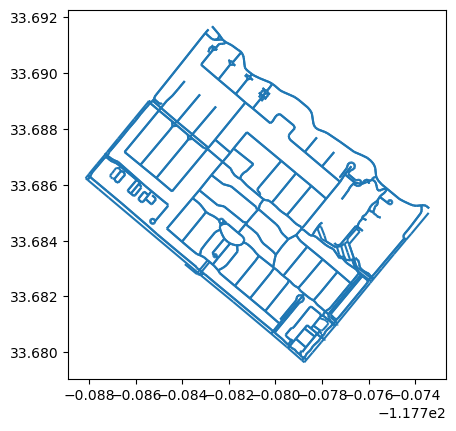

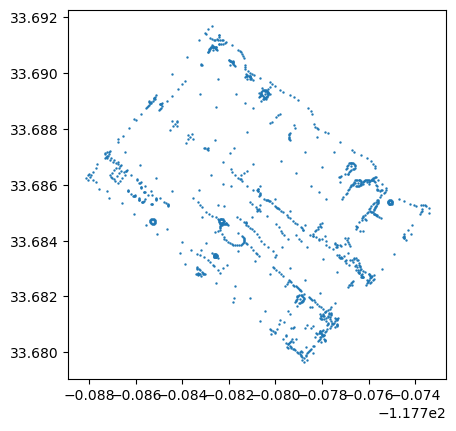

In [33]:
edges_in.plot()
nodes_in.plot(markersize=0.5)

Join nodes and edges to the census tract number they are contained within:

In [57]:
nodes_by_tract = gpd.sjoin(
    gdf_nodes.to_crs(bg.crs),
    bg[["geometry"]],
    how="inner",
    predicate="within"
)

edges_by_tract = gpd.sjoin(
    all_lts_small.to_crs(bg.crs),
    bg[["geometry"]],
    how="inner",
    predicate="within"
)

#### Network metrics - based on node and edge counts (density, low stress %, etc)

In [35]:
bg['nodes'] = nodes_by_tract.groupby('index_right')['index_right'].count()
bg['edges'] = edges_by_tract.groupby('index_right')['index_right'].count()

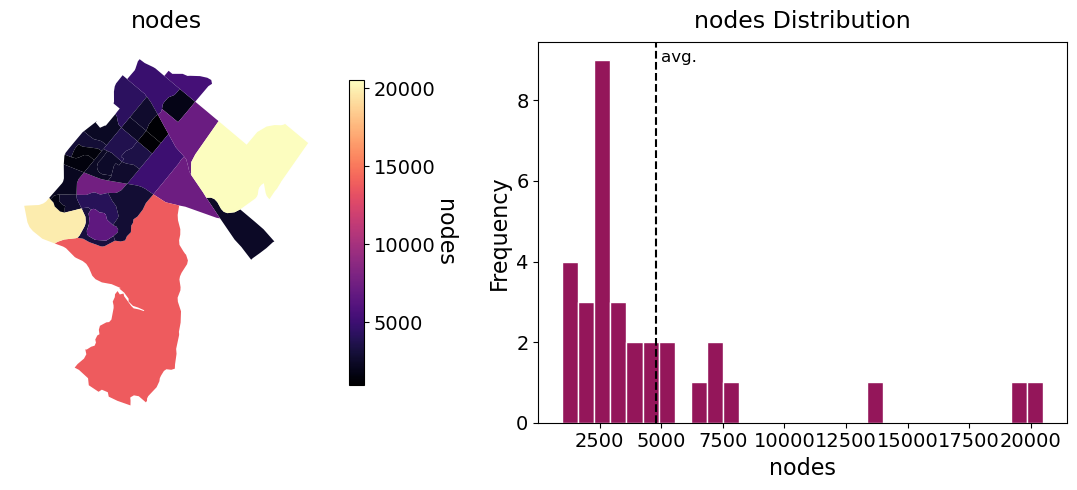

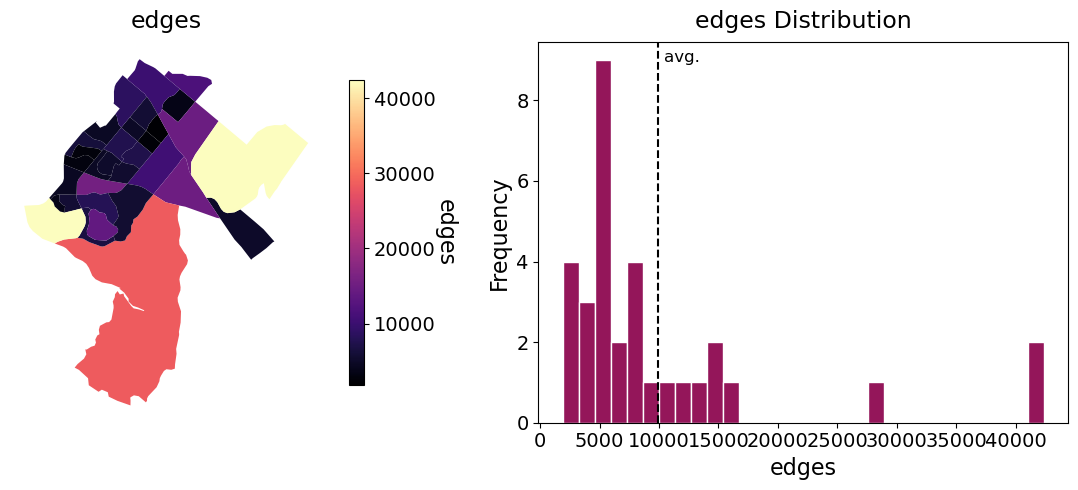

In [36]:
acquire.quick_viz(bg, "nodes")
acquire.quick_viz(bg, "edges")

Join only low-stress (both LTS<=2 and LTS=1) networks to the census tracts they are contained within:

In [37]:
nodes_by_tract_lts1 = gpd.sjoin(
    nodes_lts1.to_crs(bg.crs),
    bg[["geometry"]],
    how="inner",
    predicate="within"
)

edges_by_tract_lts1 = gpd.sjoin(
    edges_lts1.to_crs(bg.crs),
    bg[["geometry"]],
    how="inner",
    predicate="within"
)

In [38]:
nodes_by_tract_lts2 = gpd.sjoin(
    nodes_lts2.to_crs(bg.crs),
    bg[["geometry"]],
    how="inner",
    predicate="within"
)

edges_by_tract_lts2 = gpd.sjoin(
    edges_lts2.to_crs(bg.crs),
    bg[["geometry"]],
    how="inner",
    predicate="within"
)

In [39]:
bg['nodes_lts1'] = nodes_by_tract_lts1.groupby('index_right')['index_right'].count()
bg['edges_lts1'] = edges_by_tract_lts1.groupby('index_right')['index_right'].count()
bg['nodes_lts2'] = nodes_by_tract_lts2.groupby('index_right')['index_right'].count()
bg['edges_lts2'] = edges_by_tract_lts2.groupby('index_right')['index_right'].count()

In [40]:
bg['edges_lts1_pct']=bg['edges_lts1']/bg['edges']
bg['nodes_lts1_pct']=bg['nodes_lts1']/bg['nodes']

bg['edges_lts2_pct']=bg['edges_lts2']/bg['edges']
bg['nodes_lts2_pct']=bg['nodes_lts2']/bg['nodes']

bg['lts1_beta']=bg['nodes_lts1']/bg['edges_lts1']
bg['lts2_beta']=bg['nodes_lts2']/bg['edges_lts2']

bg['edges_lts1_density']=bg['edges_lts1']/bg['ALAND']
bg['nodes_lts1_density']=bg['nodes_lts1']/bg['ALAND']

bg['edges_lts2_density']=bg['edges_lts2']/bg['ALAND']
bg['nodes_lts2_density']=bg['nodes_lts2']/bg['ALAND']

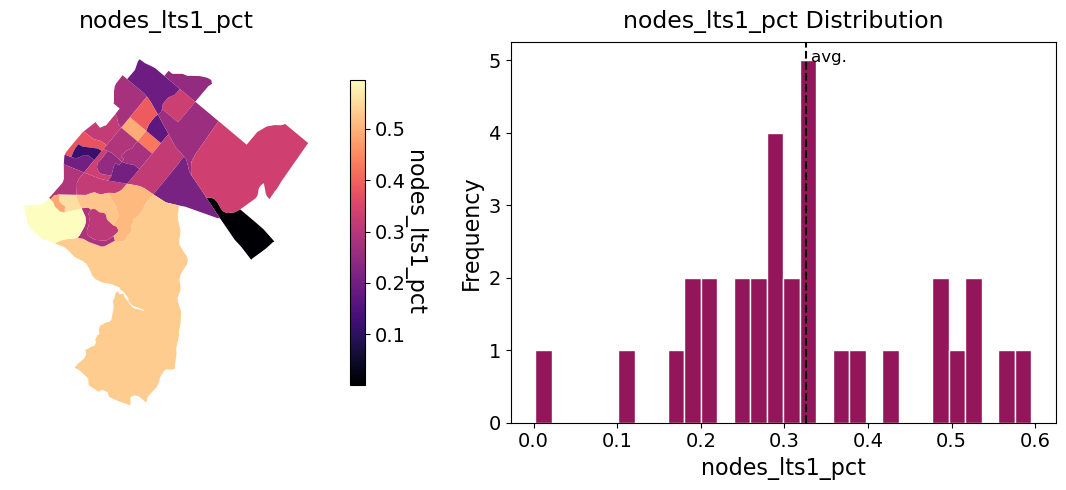

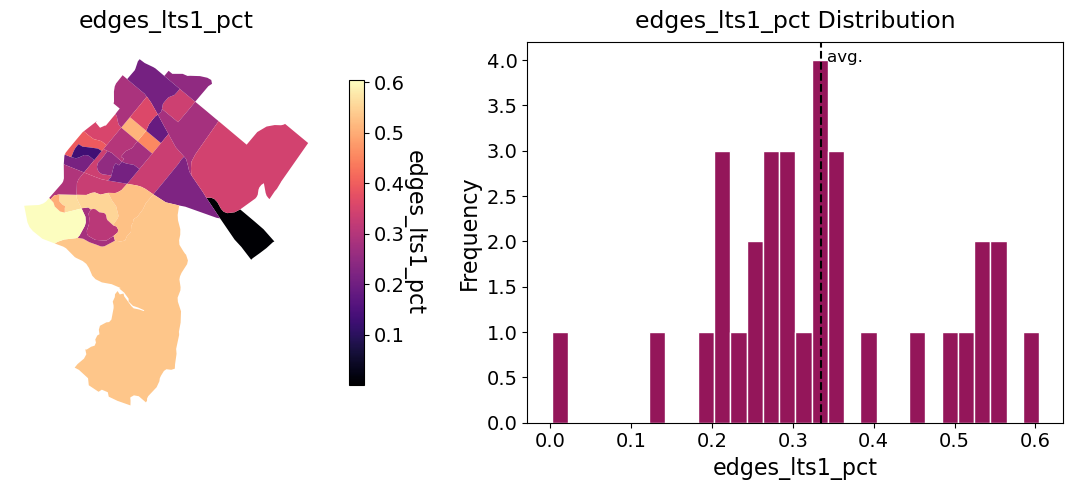

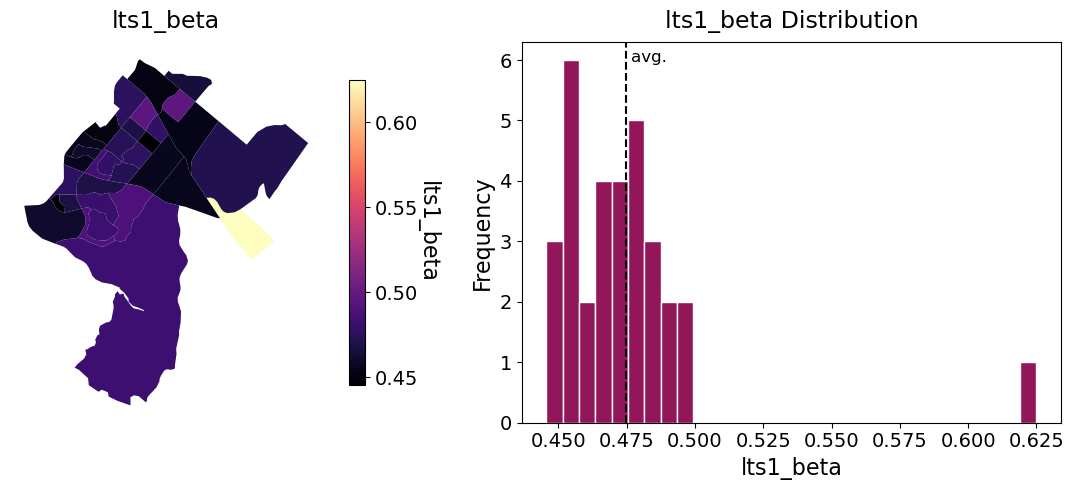

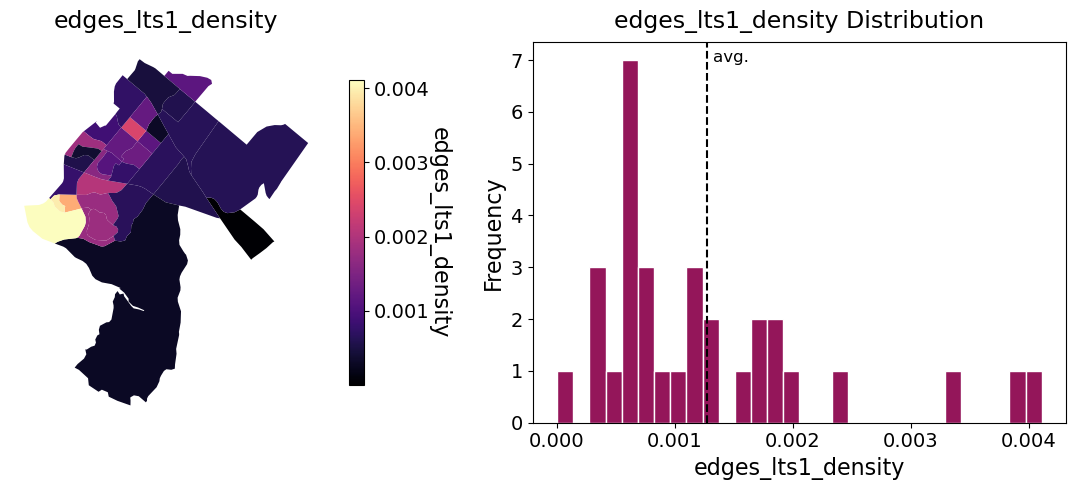

In [42]:
acquire.quick_viz(bg, "nodes_lts1_pct")
acquire.quick_viz(bg, "edges_lts1_pct")
acquire.quick_viz(bg, "lts1_beta")
acquire.quick_viz(bg, "edges_lts1_density")

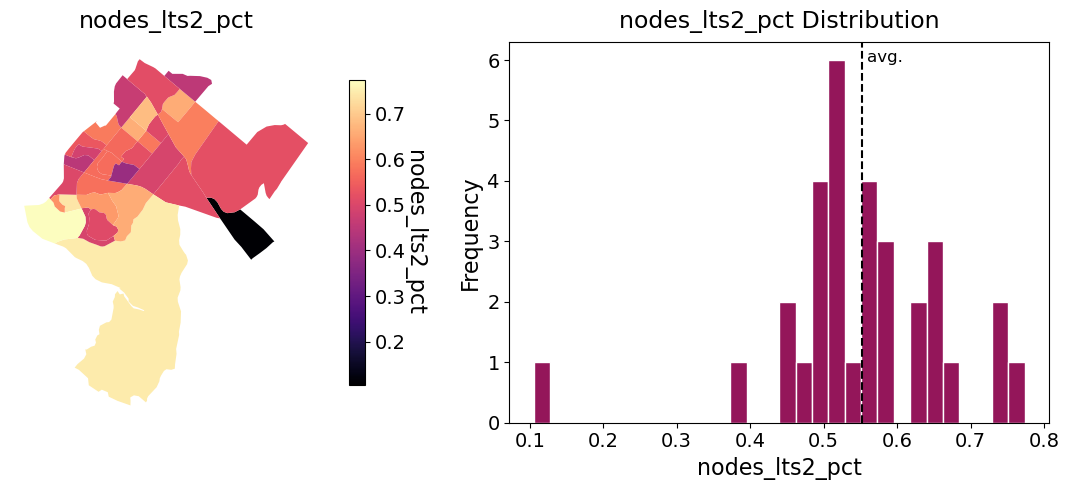

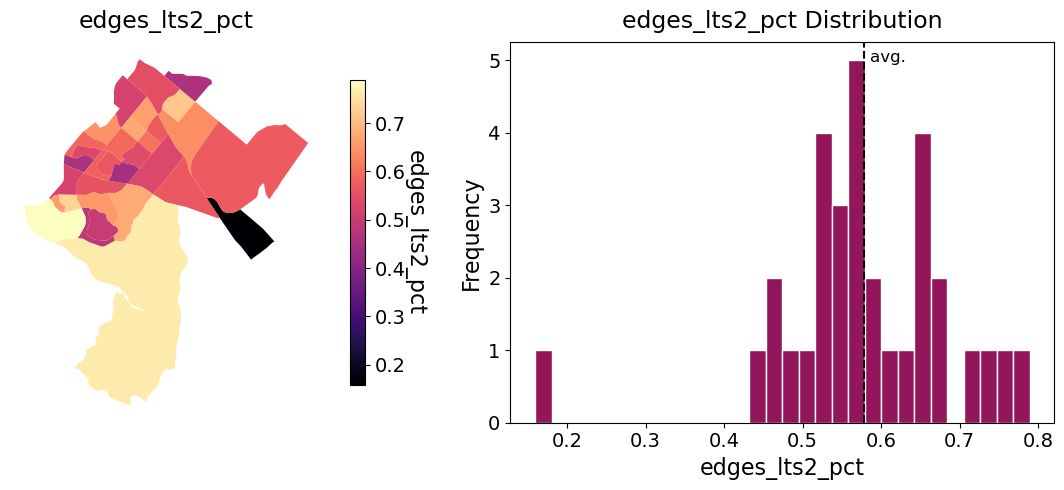

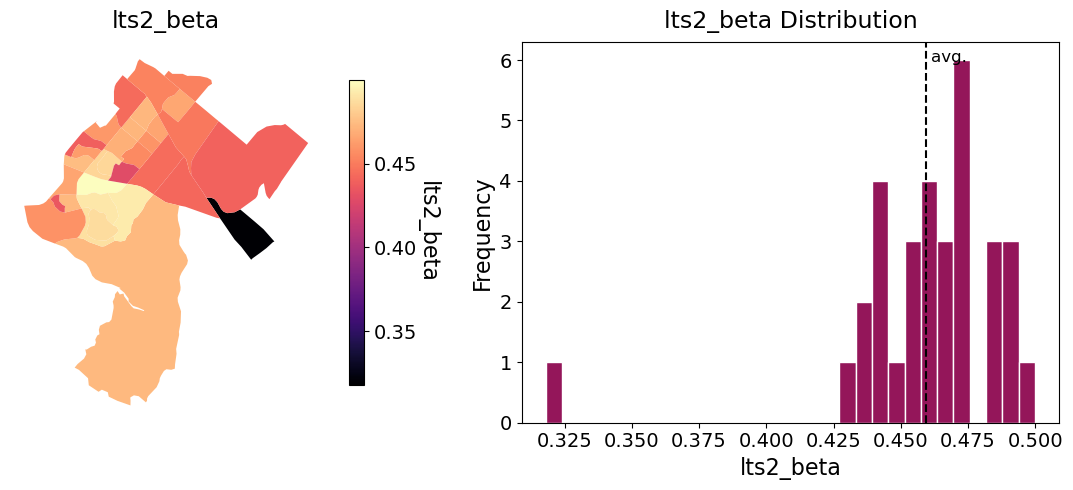

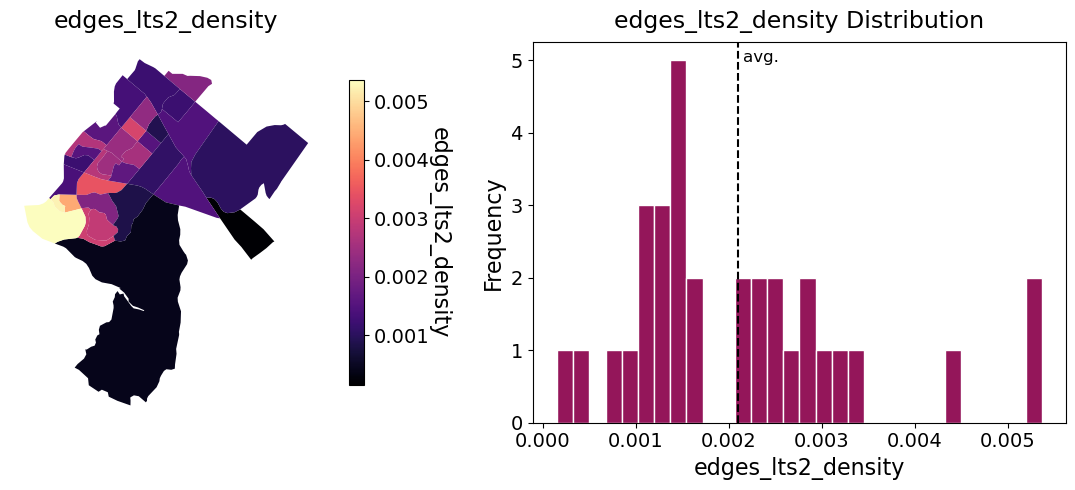

In [44]:
acquire.quick_viz(bg, "nodes_lts2_pct")
acquire.quick_viz(bg, "edges_lts2_pct")
acquire.quick_viz(bg, "lts2_beta")
acquire.quick_viz(bg, "edges_lts2_density")

#### Network metrics - based on connected component size [old/not needed]

In [45]:
## find the single largest connected component

largest_cc = max(nx.connected_components(G_low_stress1.to_undirected()), key=len)
G_lcc = G_low_stress1.subgraph(largest_cc).copy()
#fig6, ax6 = ox.plot_graph(G_lcc, node_size=1, edge_linewidth=0.3)

In [46]:
#G_low_stress1.nodes

In [ ]:
## Create a subgraph of the largest component that contains a specified node
## (eg this is the furthest extent you would be able to travel from that node staying on only low stress routes)
#s = G_low_stress1.subgraph(nx.shortest_path(G_low_stress1.to_undirected(),10079420071)) ## looking at a random arbitrary node for now
## count the number of edges in the subgraph as a proxy for subgraph size
## next step would be length
#len(s.edges)

In [ ]:
#fig7, ax7 = ox.plot_graph(s, node_size=1, edge_linewidth=0.3)

In [ ]:
## ok now how to actually add this to the dataframe
## First, add the total number of connected edges to the nodes_by_tract dataframe
## looks like the osmid #, aka the index is the same as the node # in the graph
## maybe use a lambda function and apply doesn't seem possible to vectorize


#nodes_by_tract_lowstress['lcc_size'] = nodes_by_tract_lowstress.index.to_series().apply(lambda x: 
                                                                                     #   len(G_low_stress1.subgraph(nx.shortest_path(G_low_stress1.to_undirected(), x)).edges))


In [ ]:
#bg['lcc_size_avg']=nodes_by_tract_lowstress.groupby('index_right')['lcc_size'].mean()

In [ ]:
#acquire.quick_viz(bg, "lcc_size_avg")
##seems quite similar to density
##but way more computationally intensive ..
##maybe we just use density haha
## unless I can find a better way to assign nodes to their corresponding subgraph rather than recalculating the subgraph for every node

#### More efficient/faster Connected Component/Subgraph size calculation

Create a dataframe where each row represents one connected component subgraph, with the list of all nodes in the subgraph:

In [58]:
components_lts1 = pd.DataFrame({'subgraph nodes':nx.connected_components(G_low_stress1.to_undirected())})
components_lts2 = pd.DataFrame({'subgraph nodes':nx.connected_components(G_low_stress2.to_undirected())})

Calculate # of edges per component subgraph, and total length of all edges

In [59]:
components_lts1['subgraph edge count']=components_lts1['subgraph nodes'].apply(lambda x: len(G_low_stress1.subgraph(x).edges))
components_lts2['subgraph edge count']=components_lts2['subgraph nodes'].apply(lambda x: len(G_low_stress2.subgraph(x).edges))

components_lts1['subgraph total length']=components_lts1['subgraph nodes'].apply(lambda x: ox.stats.edge_length_total(G_low_stress1.subgraph(x)))
components_lts2['subgraph total length']=components_lts2['subgraph nodes'].apply(lambda x: ox.stats.edge_length_total(G_low_stress2.subgraph(x)))

Explode such that every node in the subgraph is one row, with the corresponding subgraph length attached:

In [60]:
nodes_component_size_lts1=components_lts1.explode('subgraph nodes').reset_index()
nodes_component_size_lts2=components_lts2.explode('subgraph nodes').reset_index()

Combine back to the original dataframe of all low-stress nodes:

In [61]:
nodes_lts1=nodes_lts1.merge(nodes_component_size_lts1, left_on='osmid',right_on='subgraph nodes')
nodes_lts2=nodes_lts2.merge(nodes_component_size_lts2, left_on='osmid',right_on='subgraph nodes')

Re-join back to census tracts so we can calculate the average connected component size by census tract:

In [62]:
nodes_by_tract_lts1 = gpd.sjoin(
    nodes_lts1.to_crs(bg.crs),
    bg[["geometry"]],
    how="inner",
    predicate="within"
)
nodes_by_tract_lts2 = gpd.sjoin(
    nodes_lts2.to_crs(bg.crs),
    bg[["geometry"]],
    how="inner",
    predicate="within"
)

Aggregate at the census tract level:

In [63]:
bg['avg_component_edges_lts1']=nodes_by_tract_lts1.groupby('index_right')['subgraph edge count'].mean()
bg['avg_component_edges_lts2']=nodes_by_tract_lts2.groupby('index_right')['subgraph edge count'].mean()

bg['avg_component_length_lts1']=nodes_by_tract_lts1.groupby('index_right')['subgraph total length'].mean()
bg['avg_component_length_lts2']=nodes_by_tract_lts2.groupby('index_right')['subgraph total length'].mean()

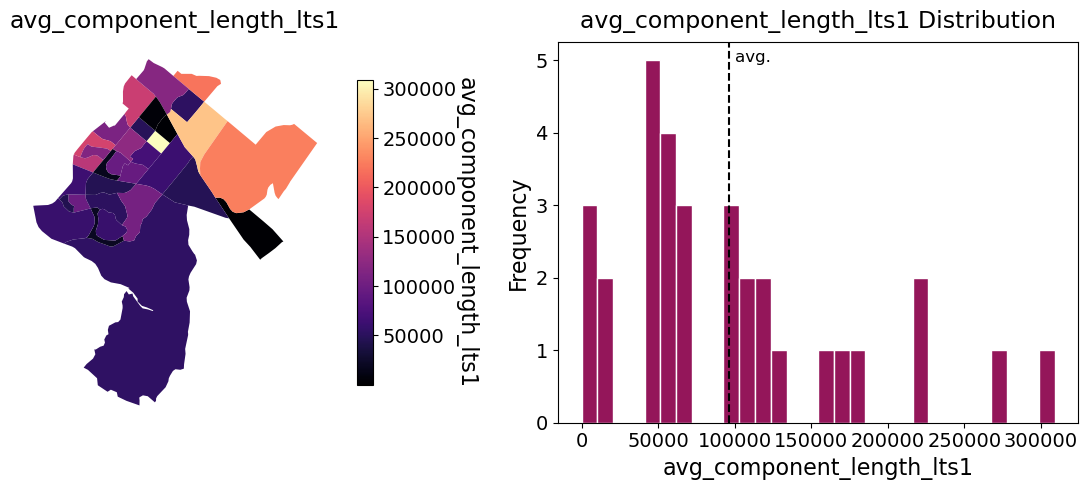

In [64]:
acquire.quick_viz(bg, "avg_component_length_lts1")

In [66]:
bg.to_csv('data/%s_network_quality_metrics.csv' %city)

In [ ]:
#[for i in nx.connected_components(G_low_stress1.to_undirected()) print i]

In [ ]:
#nodes_lcc,edges_lcc = ox.graph_to_gdfs(G_lcc)

#fig, ax = plt.subplots(figsize=(10,10))

#all_lts_small.plot(ax=ax, color="black", linewidth=0.6, zorder=1)
#ax.axis("off")

### ok in general converting back from graph to gdfs is not working, no idea why since all node and edge data seems to be fine .... 